# TF-IDF + Logistic Regression Learning Curve

This experiment evaluates how the performance of the TF-IDF + Logistic Regression baseline changes as the amount of available training data increases.

The model is trained on 1%, 5%, 12%, 17.5%, 25%, 50%, and 100% of the training set. Training and validation accuracy are recorded for each subset to examine data efficiency and generalization.

In [3]:
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_from_disk
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
from matplotlib.ticker import PercentFormatter

## 1. Load Dataset

Load the prepared three-class dataset and extract the training and validation splits used for the learning-curve experiment.

In [4]:
dataset = load_from_disk(
    "data/hf-dataset-3class-full"
)

X_train = np.asarray(
    dataset["train"]["text"],
    dtype=object,
)

y_train = np.asarray(
    dataset["train"]["label"],
    dtype=np.int64,
)

X_validation = np.asarray(
    dataset["validation"]["text"],
    dtype=object,
)

y_validation = np.asarray(
    dataset["validation"]["label"],
    dtype=np.int64,
)

## 2. Experiment Configuration

Evaluate the model using **1%, 5%, 12%, 17.5%, 25%, 50%, and 100%** of the available training data.

In [5]:
RANDOM_STATE = 17

TRAIN_FRACTIONS = np.asarray(
    [0.01, 0.05, 0.12, 0.175, 0.25, 0.50, 1.00]
)

## 3. Nested Training Order

Create a reproducible class-balanced ordering of the training samples so that each larger subset contains all samples from the smaller subsets.

In [6]:
def build_stratified_order(
    labels,
    seed,
):
    labels = np.asarray(
        labels,
        dtype=np.int64,
    )

    rng = np.random.default_rng(
        seed
    )

    classes = np.unique(
        labels
    )

    class_indices = {}

    for class_id in classes:
        indices = np.flatnonzero(
            labels == class_id
        )

        rng.shuffle(
            indices
        )

        class_indices[
            class_id
        ] = indices.tolist()

    class_proportions = {
        class_id:
            len(class_indices[class_id])
            / len(labels)
        for class_id in classes
    }

    selected = {
        class_id: 0
        for class_id in classes
    }

    order = []

    for step in range(
        len(labels)
    ):
        available = [
            class_id
            for class_id in classes
            if selected[class_id]
            < len(class_indices[class_id])
        ]

        next_class = max(
            available,
            key=lambda class_id:
                (
                    class_proportions[class_id]
                    * (step + 1)
                    - selected[class_id]
                ),
        )

        position = selected[
            next_class
        ]

        order.append(
            class_indices[
                next_class
            ][position]
        )

        selected[
            next_class
        ] += 1

    return np.asarray(
        order,
        dtype=np.int64,
    )


training_order = build_stratified_order(
    y_train,
    seed=RANDOM_STATE,
)

## 4. Training Subsets

Define the number of training samples corresponding to each learning-curve point.

In [7]:
train_sizes = np.rint(
    TRAIN_FRACTIONS
    * len(X_train)
).astype(np.int64)

train_sizes = np.unique(
    np.clip(
        train_sizes,
        3,
        len(X_train),
    )
)

train_sizes[-1] = len(
    X_train
)


subset_summary = pd.DataFrame(
    {
        "training_samples":
            train_sizes,

        "training_fraction":
            train_sizes
            / len(X_train),
    }
)

subset_summary.style.format(
    {
        "training_fraction":
            "{:.1%}",
    }
)

,training_samples,training_fraction
0,250,1.0%
1,1249,5.0%
2,2998,12.0%
3,4373,17.5%
4,6246,25.0%
5,12493,50.0%
6,24986,100.0%


## 5. Model Initialization

Define the TF-IDF + Logistic Regression pipeline using the hyperparameters selected by the original baseline grid search.

In [8]:
def create_logreg_model():
    return Pipeline(
        [
            (
                "tfidf",
                TfidfVectorizer(
                    lowercase=True,
                    max_df=0.98,
                    max_features=200_000,
                    sublinear_tf=True,
                    dtype=np.float32,
                    min_df=5,
                    ngram_range=(1, 2),
                ),
            ),
            (
                "logreg",
                LogisticRegression(
                    C=3.0,
                    max_iter=1_000,
                    random_state=RANDOM_STATE,
                    solver="lbfgs",
                ),
            ),
        ]
    )

## 6. Experiment Output

Create directories for the learning-curve results and figures.

In [9]:
OUTPUT_DIR = Path(
    "learning-curve-tfidf-logreg"
)

RESULTS_DIR = (
    OUTPUT_DIR
    / "results"
)

FIGURES_DIR = (
    OUTPUT_DIR
    / "figures"
)

RESULTS_PATH = (
    RESULTS_DIR
    / "tfidf-logreg-learning-curve.csv"
)

for directory in [
    RESULTS_DIR,
    FIGURES_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )

## 7. Learning-Curve Experiment

Train a fresh TF-IDF + Logistic Regression model on each training subset and measure training accuracy, validation accuracy, generalization gap, and training runtime.

In [10]:
learning_curve_rows = []

for sample_count in train_sizes:
    sample_count = int(
        sample_count
    )

    train_indices = training_order[
        :sample_count
    ]

    X_subset = X_train[
        train_indices
    ]

    y_subset = y_train[
        train_indices
    ]

    model = create_logreg_model()

    start_time = time.perf_counter()

    model.fit(
        X_subset,
        y_subset,
    )

    runtime = (
        time.perf_counter()
        - start_time
    )

    training_prediction = model.predict(
        X_subset
    )

    validation_prediction = model.predict(
        X_validation
    )

    training_accuracy = accuracy_score(
        y_subset,
        training_prediction,
    )

    validation_accuracy = accuracy_score(
        y_validation,
        validation_prediction,
    )

    learning_curve_rows.append(
        {
            "training_samples":
                sample_count,

            "training_fraction":
                sample_count
                / len(X_train),

            "training_accuracy":
                training_accuracy,

            "validation_accuracy":
                validation_accuracy,

            "generalization_gap":
                training_accuracy
                - validation_accuracy,

            "training_runtime_seconds":
                runtime,
        }
    )


logreg_learning_curve = pd.DataFrame(
    learning_curve_rows
)

logreg_learning_curve

,training_samples,training_fraction,training_accuracy,validation_accuracy,generalization_gap,training_runtime_seconds
0,250,0.010006,1.000000,0.762904,0.237096,1.193607
1,1249,0.049988,1.000000,0.842051,0.157949,3.325757
2,2998,0.119987,1.000000,0.871989,0.128011,9.561443
3,4373,0.175018,0.998857,0.881624,0.117232,14.685970
4,6246,0.249980,0.999199,0.889883,0.109316,18.425099
5,12493,0.500000,0.997679,0.903304,0.094375,32.971761
6,24986,1.000000,0.995397,0.913283,0.082115,72.356065


## 8. Learning-Curve Results

Collect, save, and format the performance measurements obtained for each training-set size.

In [11]:
logreg_learning_curve.to_csv(
    RESULTS_PATH,
    index=False,
)

logreg_learning_curve.style.format(
    {
        "training_fraction":
            "{:.1%}",

        "training_accuracy":
            "{:.2%}",

        "validation_accuracy":
            "{:.2%}",

        "generalization_gap":
            "{:.2%}",

        "training_runtime_seconds":
            "{:,.1f}",
    }
)

,training_samples,training_fraction,training_accuracy,validation_accuracy,generalization_gap,training_runtime_seconds
0,250,1.0%,100.00%,76.29%,23.71%,1.2
1,1249,5.0%,100.00%,84.21%,15.79%,3.3
2,2998,12.0%,100.00%,87.20%,12.80%,9.6
3,4373,17.5%,99.89%,88.16%,11.72%,14.7
4,6246,25.0%,99.92%,88.99%,10.93%,18.4
5,12493,50.0%,99.77%,90.33%,9.44%,33.0
6,24986,100.0%,99.54%,91.33%,8.21%,72.4


## 9. Learning-Curve Visualization

Plot training and validation accuracy against the percentage of training data used to visualize how model performance changes with dataset size.

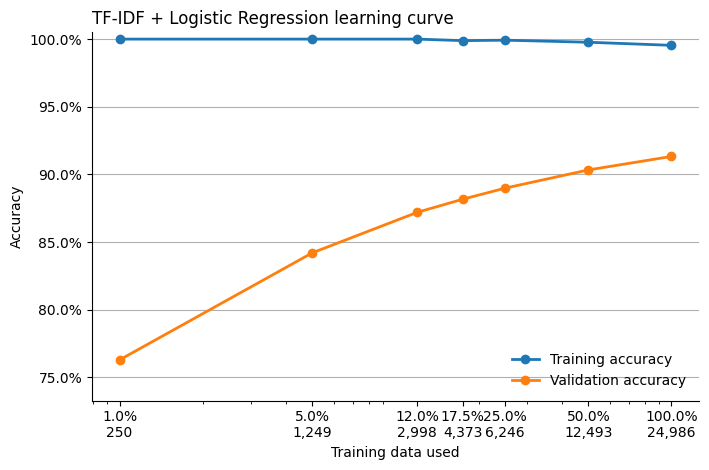

In [13]:
logreg_learning_curve = (
    logreg_learning_curve
    .sort_values(
        "training_fraction"
    )
    .reset_index(
        drop=True
    )
)

x_percent = (
    logreg_learning_curve[
        "training_fraction"
    ].to_numpy()
    * 100
)

training_accuracy = (
    logreg_learning_curve[
        "training_accuracy"
    ].to_numpy()
)

validation_accuracy = (
    logreg_learning_curve[
        "validation_accuracy"
    ].to_numpy()
)

fig, ax = plt.subplots(
    figsize=(7.2, 4.8)
)

ax.plot(
    x_percent,
    training_accuracy,
    marker="o",
    linewidth=2,
    label="Training accuracy",
)

ax.plot(
    x_percent,
    validation_accuracy,
    marker="o",
    linewidth=2,
    label="Validation accuracy",
)

ax.set_xscale(
    "log"
)

ax.set_xticks(
    x_percent,
    [
        (
            f"{fraction:.1f}%\n"
            f"{samples:,}"
        )
        for fraction, samples
        in zip(
            x_percent,
            logreg_learning_curve[
                "training_samples"
            ],
        )
    ],
)

lower_limit = max(
    0.5,
    min(
        training_accuracy.min(),
        validation_accuracy.min(),
    )
    - 0.03,
)

ax.set_ylim(
    lower_limit,
    1.005,
)

ax.yaxis.set_major_formatter(
    PercentFormatter(1.0)
)

ax.set_xlabel(
    "Training data used"
)

ax.set_ylabel(
    "Accuracy"
)

ax.set_title(
    "TF-IDF + Logistic Regression learning curve",
    loc="left",
)

ax.grid(
    axis="y",
    linewidth=0.8,
)

ax.spines[
    ["top", "right"]
].set_visible(
    False
)

ax.legend(
    frameon=False,
    loc="lower right",
)

fig.tight_layout()

FIGURE_PATH = (
    FIGURES_DIR
    / "tfidf-logreg-learning-curve.svg"
)

fig.savefig(
    FIGURE_PATH,
    bbox_inches="tight",
)

plt.show()